# Assignment 6
### Do Question 6, and three more questions of your choice.

### 1. Set review:

- Operations on sets (hints: sketch venn-type diagrams, and showing $A=B$ is the same as $A \subseteq B$ and $B \subseteq A$):
- $ (A \backslash B) \cup (A \cap B) = A $
- $ A \cup ( B \cap C) = (A \cup B) \cap (A \cup C)$
- $ A \backslash (B \cup C) = A\backslash B \cap A \backslash C $ and $A \backslash (B \cap C) = A \backslash B \cup A \backslash C$

- Plot the following sets:
    - $A = \{x \in \mathbb{R}: x^2 -1 \ge 0 \}$
    - $B = \{ (x,y) \in \mathbb{R}^2: 3x -2y \ge 0 \}$
    - $C = \{ (x,y) \in \mathbb{R}^2: xy \ge 3 \}$
    - $D = \{ (x_1,x_2) \in \mathbb{R}^2: x_1 \ge 0, x_2 \ge 0, x_1 + x_2 \le 1 \}$
- The power set of $A$ is the set of all subsets of $A$, denoted $\mathcal{P}(A)$. What is the power set of $\{ 1, 2, 3 \}$? (Hint: The empty set is a subset of every set; the whole set is a subset of itself.)

### 2. Probability space basics:

- What are the outcomes for rolling a single, fair **THREE**-sided die? What's the set of all events? What are the probabilities of all the events?
- What about flipping a fair coin twice? (Hint: There are 4 outcomes, and $2^{4} = 16$ events.)
- What about rolling the **THREE**-sided die twice, and adding the results? Don't write down the set of all the possible events, but describe briefly what it looks like and how large it is. (Hint: There are 5 outcomes, and $2^{5}=32$ possible events.)

Obviously, a "three-sided die" doesn't exist, but this keeps you from spending a lot of time suffering in working out sets of events.

- The outcomes for rolling a single three sided die are one, two, and three. The set of all events is {1,2,3}. The probability of all three events is 1/3.
- The outcomes for flipping a fair coin twice are HH,HT,TH,TT. There are 16 total events because there are 4 events in the outcome set of size two, so including the sublists there are 16 possibilities. The  probability of each of the outcomes is 1/4.
- Rolling a three sided die twice and adding the results will have outcomes of {2,3,4,5,6}. This situation has 32 possible events since the set of all possible events consists of every subset of the five summed outcomes, so it is the power of the set and contains 2^5 = 32 outcomes.


### 3. Random Variable Basics

- Imagine rolling a fair single six-sided die. There are 6 outcomes, all equally likely. Derive the sample space and the space of events. What are the probabilities of the outcomes and events?
- Consider a random variable that assigns the square root of the number of pips on the die to each outcome. Write code to simulate rolling a single six-sided die and computing the value of the random variable. Simulate 5000 rolls and plot the mass function and ECDF of the random variable.
- Imagine rolling two fair six-sided die. Consider a random variable that adds up the pips on the dice. There are 11 outcomes (2 , 3, ..., 12), but not all are equally likely. Derive the sample space and **describe** the space of events. What are the probabilities of the outcomes?
- Write code to simulate the random variable (rolling two six-sided die and adding the results together). Simulate 10000 rolls and plot the mass function and ECDF.

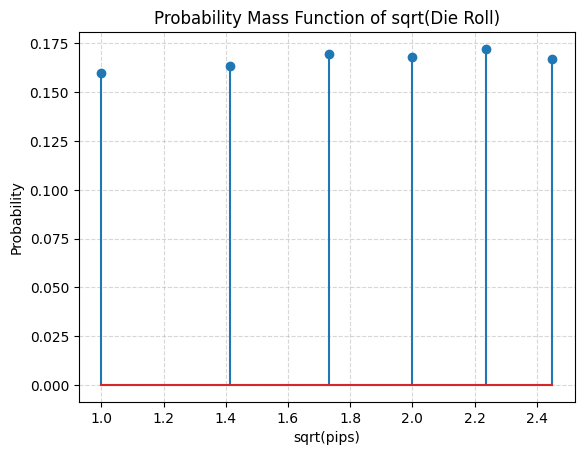

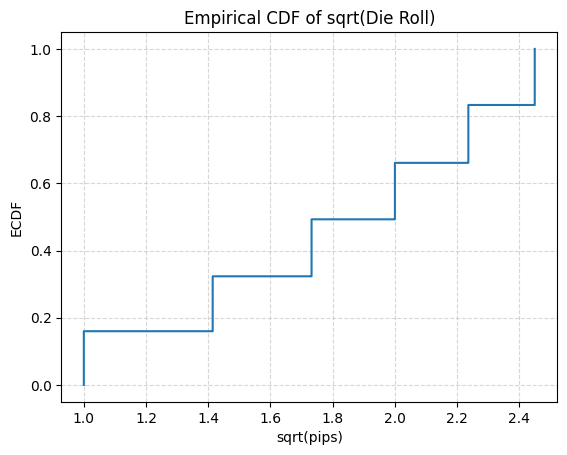

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate 5000 rolls of a fair six-sided die
n = 5000
rolls = np.random.randint(1, 7, n)
X = np.sqrt(rolls)

# Compute the PMF
unique_vals, counts = np.unique(X, return_counts=True)
pmf = counts / n

# Plot PMF
plt.figure()
plt.stem(unique_vals, pmf)
plt.xlabel("sqrt(pips)")
plt.ylabel("Probability")
plt.title("Probability Mass Function of sqrt(Die Roll)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Compute ECDF
sorted_X = np.sort(X)
ecdf = np.arange(1, n + 1) / n

# Plot ECDF
plt.figure()
plt.step(sorted_X, ecdf, where="post")
plt.xlabel("sqrt(pips)")
plt.ylabel("ECDF")
plt.title("Empirical CDF of sqrt(Die Roll)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Each die has outcomes {1,2,3,4,5,6}, so combined they have 11 outcomes. The space of events is {2,3,4,5,6,7,8,9,10,11,12} and all subsets, so the event space is the power set of this space of events and has 2^11=2048 possible outcomes. The probability of 2 and 12 is 1/36, the probability of 3 and 11 is
2/36, the probability of 4 and 10 is 3/36, the probability of 5 and 9 is 4/36, the probability of 6 and 8 is 5/36, and the probability of 7 is 1/6.

The sample space is {1,2,3,4,5,6}, and the space of all events is the set of all events, which includes all subsets of {1,2,3,4,5,6} and has 2^6 = 64 possible events.  The probability of each outcome is 1/6.

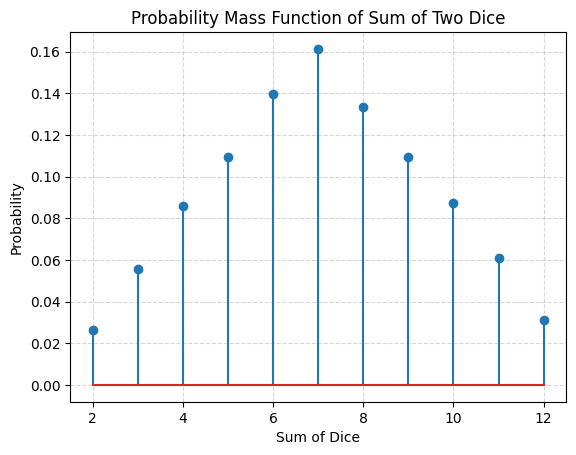

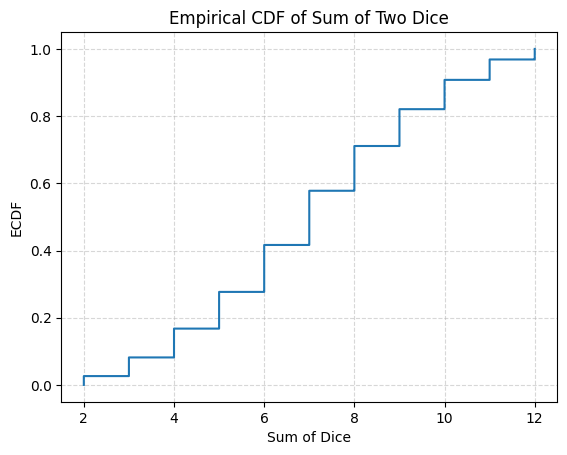

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate 10000 rolls of two fair six-sided dice
n = 10000
die1 = np.random.randint(1, 7, n)
die2 = np.random.randint(1, 7, n)
X = die1 + die2

# Compute the PMF
values, counts = np.unique(X, return_counts=True)
pmf = counts / n

# Plot PMF
plt.figure()
plt.stem(values, pmf)
plt.xlabel("Sum of Dice")
plt.ylabel("Probability")
plt.title("Probability Mass Function of Sum of Two Dice")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Compute ECDF
sorted_X = np.sort(X)
ecdf = np.arange(1, n + 1) / n

# Plot ECDF
plt.figure()
plt.step(sorted_X, ecdf, where="post")
plt.xlabel("Sum of Dice")
plt.ylabel("ECDF")
plt.title("Empirical CDF of Sum of Two Dice")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### 4. Roulette

This question will be easiest if you read the whole thing, and come up with a clear plan for how you'll write the code.

Roulette is a betting game. There are 37 possible outcomes: A green 0, and the numbers 1 to 36 in red and black. Here is a picture of the (American, not Euro, it has an extra green 00) betting board:

![Roulette](./src/euro_roulette.jpg)

To bet, you must pay a dollar, but then you get payouts that depend on how many slots are in your bet
- Basic bets:
    - Red or Black slots
    - Odd or Even slots
    - A single slots, like 20
- More complex bets:
    - Split: Two adjacent slots (e.g. {1,2})
    - Square: Four adjacent slots (e.g. {1,2,4,5})
    - Street: Three slots in a row (e.g. {1,2,3})
    - Line: Six slots (e.g. {1,2,3,4,5,6})
In general, you can only bet on 1, 2, 3, 4, 6 slots, 12 slots, or 18 slots. If your bet occurs when the wheel is spun, you gain 36/K-1 where $K$ is the number of slots you bet on; if not, you lose a dollar and get -1.

- Write code to model spinning the roulette wheel, including the colors and numbers (you could make two lists of number and color and draw a random number between 0 and 37... or use a dataframe with color and number variables and sample it... or use a dict with key to number/color pairs...)
- Describe the probability space associated with the roulette wheel: Outcomes, events, probabilities (If there are 37 outcomes, there are $2^{37}= 137,438,953,472$ events, by the way)
- You wrote code to generate a spin of the roulette wheel. Now write a function that takes a basic or complex bet as an argument, and returns the result for the player (win or lose, and the payout 36/K-1 or -1)
- Simulate betting on red, betting on odd, betting on 7, a split, and a line 1000 times each.
- Compute the average values for the bets you just simulated. What are the expected average payoffs?

### 5. CDF and PDF Basics

- Verify the following functions are distribution functions and compute their density functions. Plot the distribution and density.

1. $F(x) = \begin{cases}
0, & x \le 0 \\
\sqrt{x}, & 0 \le x \le 1 \\
1, & x \ge 1
\end{cases}
$
2. $F(x) = \dfrac{1}{1+e^{-x}}$
3. For $ a < b < c$,
$
F(x) = \begin{cases}
0, & x \le 0 \\
\frac{(x-a)^2}{(b-a)(b-c)}, & a \le x \le c \\
1 - \frac{(b-x)^2}{(b-a)(b-c)}, & c < x < b \\
1, & x \ge b
\end{cases}
$
4. $ F(x) = \begin{cases}
0, & x <0 \\
1 - e^{-x}, & x>0
\end{cases}
$
5. $ F(x) = \begin{cases}
0, & x \le 0 \\
x, & 0 < x < 1\\
1, & x \ge 1
\end{cases}
$

All five of these are distribution functions, the code below answers other parts of prompt.

/tmp/ipython-input-1312982431.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.where(x <= 0, 0, np.where(x < 1, np.sqrt(x), 1))
/tmp/ipython-input-1312982431.py:11: RuntimeWarning: invalid value encountered in sqrt
  return np.where((x > 0) & (x < 1), 1/(2*np.sqrt(x)), 0)


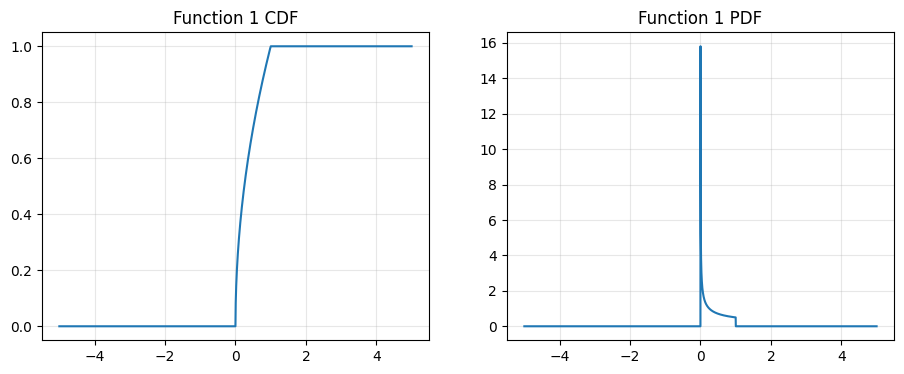

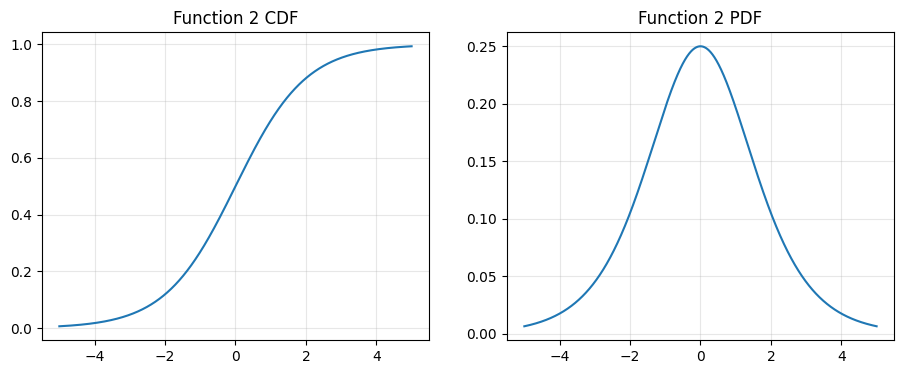

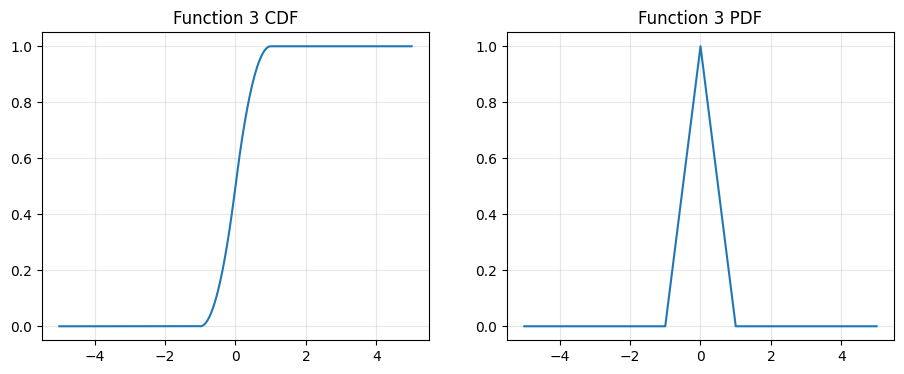

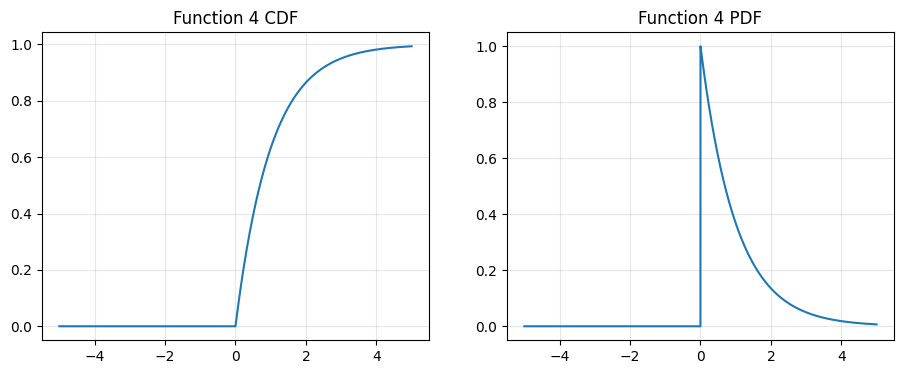

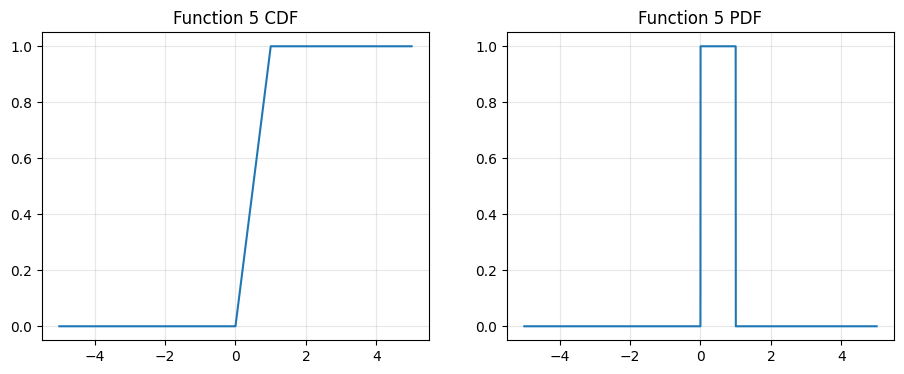

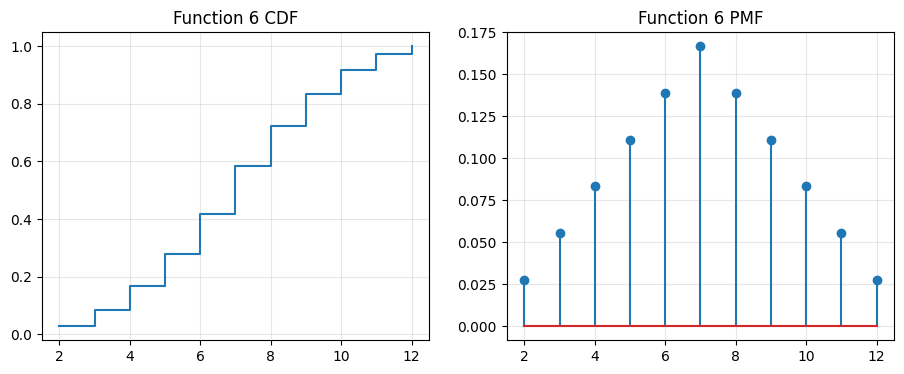


Density Functions:
1. 1/(2√x) for 0<x<1
2. e^(-x)/(1+e^(-x))^2
3. Piecewise linear between a<x<c<x<b
4. e^(-x) for x>0
5. 1 for 0<x<1
6. Dice PMF: [0.02777778 0.05555556 0.08333333 0.11111111 0.13888889 0.16666667
 0.13888889 0.11111111 0.08333333 0.05555556 0.02777778]


In [12]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 5000)

# 1
def F1(x):
    return np.where(x <= 0, 0, np.where(x < 1, np.sqrt(x), 1))

def f1(x):
    return np.where((x > 0) & (x < 1), 1/(2*np.sqrt(x)), 0)

# 2
def F2(x):
    return 1/(1 + np.exp(-x))

def f2(x):
    return np.exp(-x)/((1 + np.exp(-x))**2)

# 3 (a < c < b)
a, c, b = -1, 0, 1
def F3(x):
    return np.where(x <= a, 0,
           np.where(x <= c, (x-a)**2/((b-a)*(b-c)),
           np.where(x < b, 1 - (b-x)**2/((b-a)*(b-c)), 1)))

def f3(x):
    return np.where((x > a) & (x <= c), 2*(x-a)/((b-a)*(b-c)),
           np.where((x > c) & (x < b), 2*(b-x)/((b-a)*(b-c)), 0))

# 4
def F4(x):
    return np.where(x <= 0, 0, 1 - np.exp(-x))

def f4(x):
    return np.where(x > 0, np.exp(-x), 0)

# 5
def F5(x):
    return np.where(x <= 0, 0, np.where(x < 1, x, 1))

def f5(x):
    return np.where((x > 0) & (x < 1), 1, 0)

# 6 (dice)
dice_vals = np.arange(2, 13)
dice_probs = np.array([1,2,3,4,5,6,5,4,3,2,1]) / 36
dice_cdf = np.cumsum(dice_probs)

def plot_both(F, f, title):
    fig, axs = plt.subplots(1, 2, figsize=(11,4))
    axs[0].plot(x, F(x)); axs[0].set_title(title + " CDF"); axs[0].grid(True, alpha=0.3)
    axs[1].plot(x, f(x)); axs[1].set_title(title + " PDF"); axs[1].grid(True, alpha=0.3)
    plt.show()

plot_both(F1, f1, "Function 1")
plot_both(F2, f2, "Function 2")
plot_both(F3, f3, "Function 3")
plot_both(F4, f4, "Function 4")
plot_both(F5, f5, "Function 5")

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.step(dice_vals, dice_cdf, where="post"); plt.title("Function 6 CDF"); plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
plt.stem(dice_vals, dice_probs); plt.title("Function 6 PMF"); plt.grid(True, alpha=0.3)
plt.show()

print("\nDensity Functions:")
print("1. 1/(2√x) for 0<x<1")
print("2. e^(-x)/(1+e^(-x))^2")
print("3. Piecewise linear between a<x<c<x<b")
print("4. e^(-x) for x>0")
print("5. 1 for 0<x<1")
print("6. Dice PMF:", dice_probs)


### 6. Some Common Distributions

For the following distributions:
- Determine the support
- Compute the density from the distribution for the logistic and exponential distributions (take a derivative)
- Plot the density and distribution for a variety of parameter values
- Take a sample of 1000 draws $(x_1, x_2, ..., x_{1000})$ from the distribution, plot a KDE and ECDF, visually compare with the theoretical pdf/cdf
- Find an example of this general type of PDF/CDF from the Metabric cancer data

You can use https://docs.scipy.org/doc/scipy/reference/stats.html to generate values for the pdf/cdf and generate samples of random variates.


- Logistic distribution (similar to normal):
$$
F(x; \sigma) = \dfrac{1}{1+e^{-x/\sigma}}
$$
with $\sigma >0$.
- Exponential distribution (similar to log-normal):
$$
F_X(x) = \begin{cases}
0, & x<0 \\
1 - e^{-\lambda x}, & x \ge 0,
\end{cases}
$$
with $\lambda > 0$.
- Negative Binomial (similar to Poisson): The probability mass function for positive integers is:
$$
f(k;r,p) = \dfrac{(k+r-1)!}{k!(r-1)!}(1-p)^k p^r, \quad \text{ for $k=0,...n$}
$$
You can interpret this as follows: Flip a coin that comes up heads with probability $p$ until you get $r$ heads, and then stop. What is the probability of stopping at each $k=0,1,2,...$?
- Categorical (similar to Bernoulli): The probability mass function over $k = 1, 2, ..., K$ categories is
$$
f(k;p_1,...,p_K) = p_1^{k=1}p_2^{k=2}...p_K^{k=K}
$$
where $0 \le p_i \le 1$ and $ \sum_{k=1}^K p_k = 1$.


Supports:
Logistic: x in (-inf, inf), sigma > 0
Exponential: x in [0, inf), lambda > 0


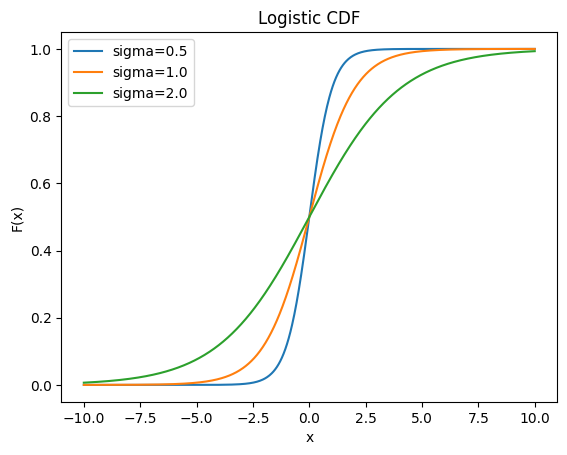

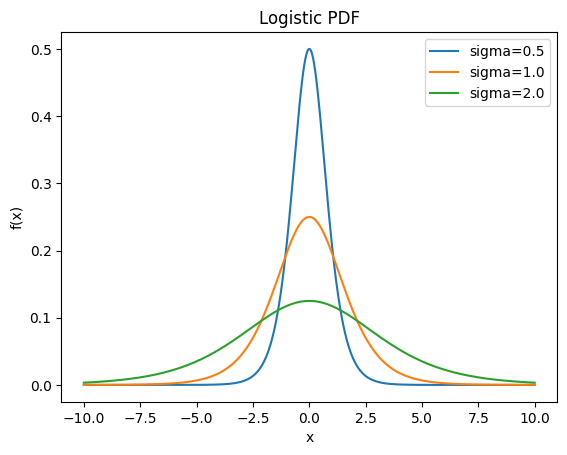

Max |pdf - d/dx cdf| for logistic (sigma=1): 1.3050584396934184e-05


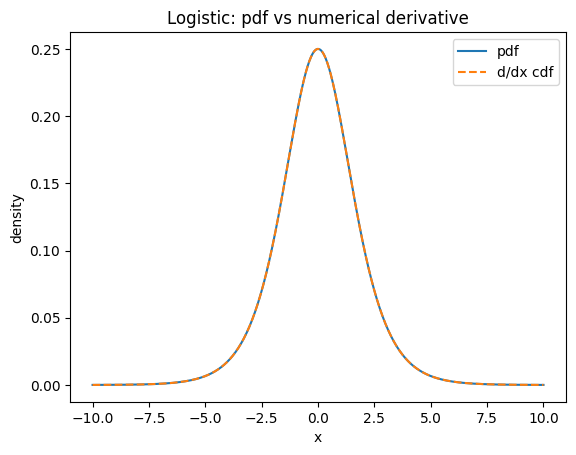

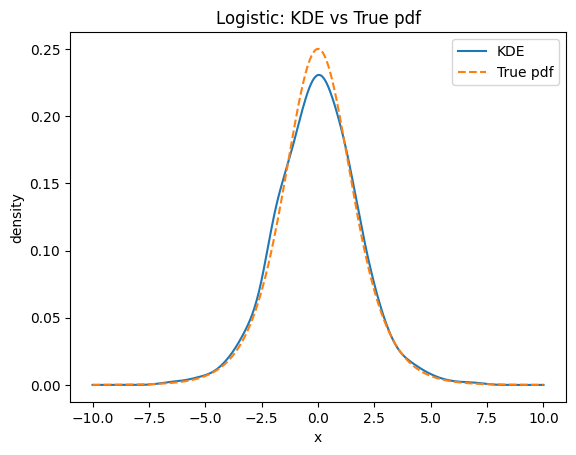

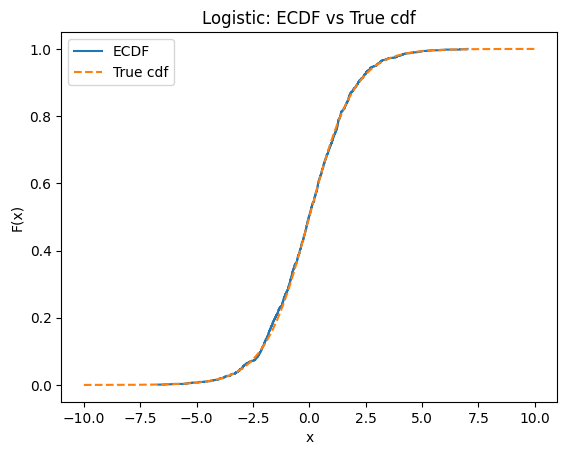

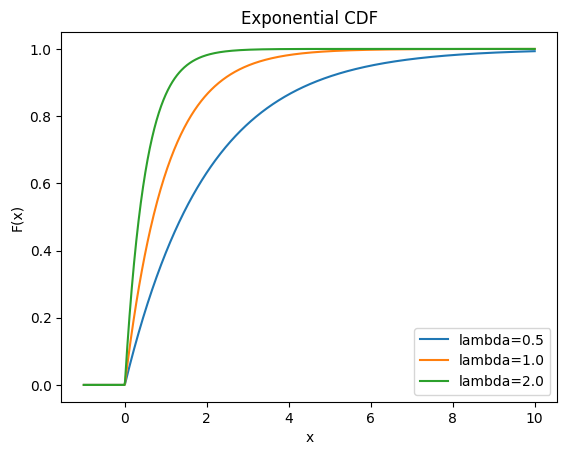

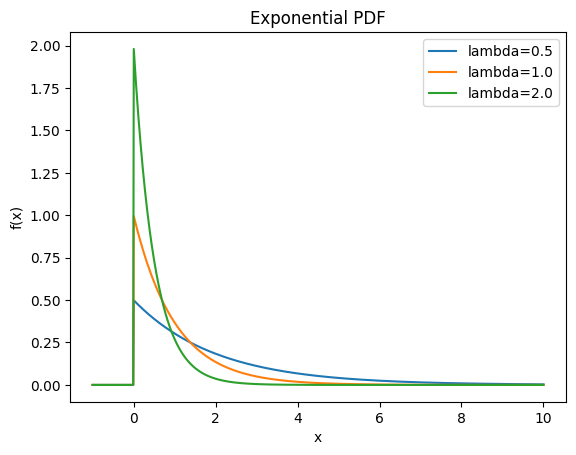

Max |pdf - d/dx cdf| for exponential (lambda=1): 0.3195482532141768


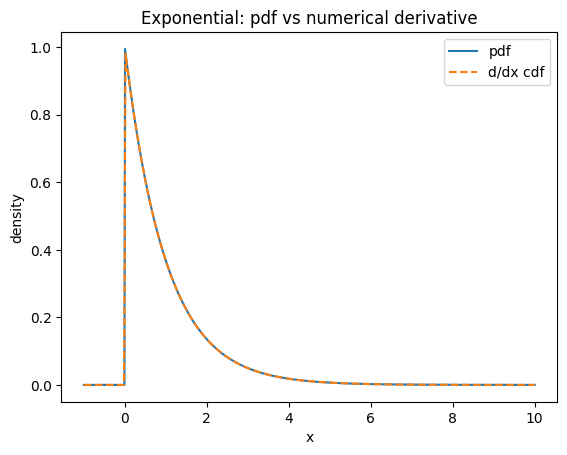

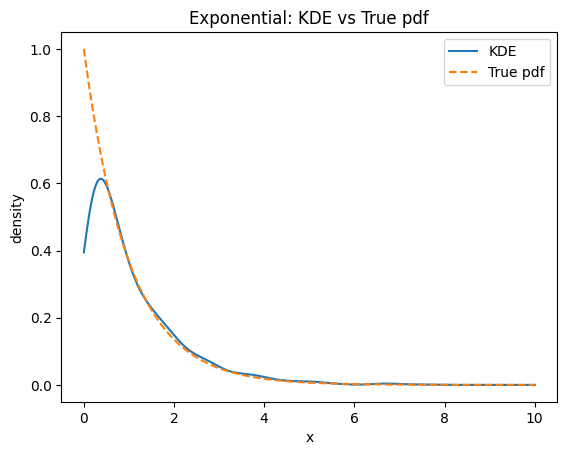

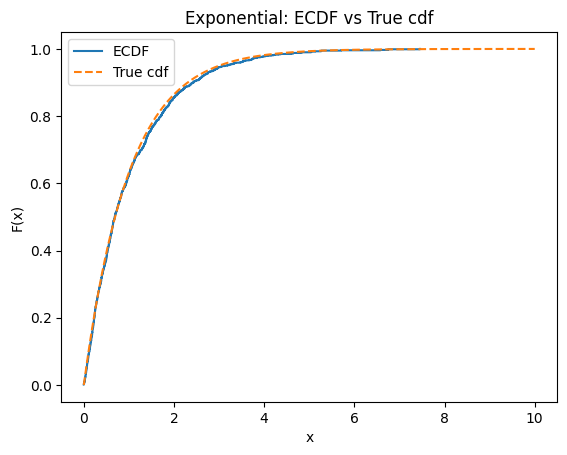

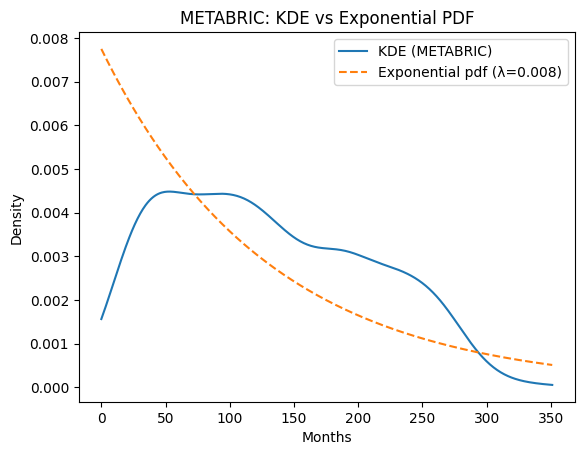

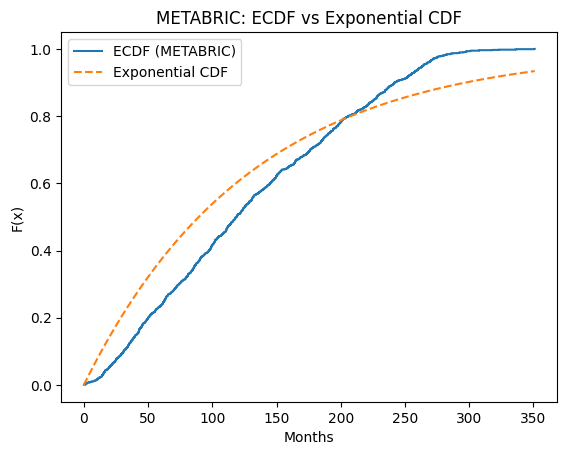

In [13]:
#AI Assisted Code


# Logistic & Exponential: support, pdf from cdf (via derivative), plots, sampling, KDE & ECDF
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---------- helpers ----------
def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, x.size + 1) / x.size
    return x, y

def gaussian_kde_manual(samples, grid):
    # Silverman's rule
    n = samples.size
    std = np.std(samples, ddof=1)
    h = 1.06 * std * n ** (-1/5)
    h = max(h, 1e-3)
    u = (grid[:, None] - samples[None, :]) / h
    kernel_vals = np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
    kde = kernel_vals.mean(axis=1) / h
    return kde

# ---------- distributions ----------
def logistic_cdf(x, sigma):
    return 1.0 / (1.0 + np.exp(-x / sigma))

def logistic_pdf(x, sigma):
    e = np.exp(-x / sigma)
    return (e / (sigma * (1 + e)**2))

def exp_cdf(x, lambda_):
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)
    mask = x >= 0
    out[mask] = 1.0 - np.exp(-lambda_ * x[mask])
    return out

def exp_pdf(x, lambda_):
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)
    mask = x >= 0
    out[mask] = lambda_ * np.exp(-lambda_ * x[mask])
    return out

# ---------- supports ----------
print("Supports:")
print("Logistic: x in (-inf, inf), sigma > 0")
print("Exponential: x in [0, inf), lambda > 0")

# ---------- plot logistic CDFs ----------
x_log = np.linspace(-10, 10, 800)
sigmas = [0.5, 1.0, 2.0]

plt.figure()
for s in sigmas:
    plt.plot(x_log, logistic_cdf(x_log, s), label=f"sigma={s}")
plt.title("Logistic CDF")
plt.xlabel("x"); plt.ylabel("F(x)")
plt.legend()
plt.show()

# ---------- plot logistic PDFs ----------
plt.figure()
for s in sigmas:
    plt.plot(x_log, logistic_pdf(x_log, s), label=f"sigma={s}")
plt.title("Logistic PDF")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.legend()
plt.show()

# ---------- derivative check for logistic ----------
F = logistic_cdf(x_log, 1.0)
dF_num = np.gradient(F, x_log)
f_true = logistic_pdf(x_log, 1.0)
print("Max |pdf - d/dx cdf| for logistic (sigma=1):", np.max(np.abs(f_true - dF_num)))

plt.figure()
plt.plot(x_log, f_true, label="pdf")
plt.plot(x_log, dF_num, "--", label="d/dx cdf")
plt.title("Logistic: pdf vs numerical derivative")
plt.xlabel("x"); plt.ylabel("density")
plt.legend()
plt.show()

# ---------- logistic sampling, KDE, ECDF ----------
sigma_samp = 1.0
u = rng.uniform(size=1000)
logistic_samples = sigma_samp * np.log(u / (1 - u))

grid_log = np.linspace(-10, 10, 600)
kde_log = gaussian_kde_manual(logistic_samples, grid_log)

plt.figure()
plt.plot(grid_log, kde_log, label="KDE")
plt.plot(grid_log, logistic_pdf(grid_log, sigma_samp), "--", label="True pdf")
plt.title("Logistic: KDE vs True pdf")
plt.xlabel("x"); plt.ylabel("density")
plt.legend()
plt.show()

xs, ys = ecdf(logistic_samples)
plt.figure()
plt.step(xs, ys, where="post", label="ECDF")
plt.plot(grid_log, logistic_cdf(grid_log, sigma_samp), "--", label="True cdf")
plt.title("Logistic: ECDF vs True cdf")
plt.xlabel("x"); plt.ylabel("F(x)")
plt.legend()
plt.show()

# ---------- exponential CDFs ----------
x_exp = np.linspace(-1, 10, 800)
lambdas = [0.5, 1.0, 2.0]

plt.figure()
for lam in lambdas:
    plt.plot(x_exp, exp_cdf(x_exp, lam), label=f"lambda={lam}")
plt.title("Exponential CDF")
plt.xlabel("x"); plt.ylabel("F(x)")
plt.legend()
plt.show()

# ---------- exponential PDFs ----------
plt.figure()
for lam in lambdas:
    plt.plot(x_exp, exp_pdf(x_exp, lam), label=f"lambda={lam}")
plt.title("Exponential PDF")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.legend()
plt.show()

# ---------- derivative check for exponential ----------
F = exp_cdf(x_exp, 1.0)
dF_num = np.gradient(F, x_exp)
f_true = exp_pdf(x_exp, 1.0)
print("Max |pdf - d/dx cdf| for exponential (lambda=1):", np.max(np.abs(f_true - dF_num)))

plt.figure()
plt.plot(x_exp, f_true, label="pdf")
plt.plot(x_exp, dF_num, "--", label="d/dx cdf")
plt.title("Exponential: pdf vs numerical derivative")
plt.xlabel("x"); plt.ylabel("density")
plt.legend()
plt.show()

# ---------- exponential sampling, KDE, ECDF ----------
lambda_samp = 1.0
u = rng.uniform(size=1000)
exp_samples = -np.log(1 - u) / lambda_samp

grid_exp = np.linspace(0, 10, 600)
kde_exp = gaussian_kde_manual(exp_samples, grid_exp)

plt.figure()
plt.plot(grid_exp, kde_exp, label="KDE")
plt.plot(grid_exp, exp_pdf(grid_exp, lambda_samp), "--", label="True pdf")
plt.title("Exponential: KDE vs True pdf")
plt.xlabel("x"); plt.ylabel("density")
plt.legend()
plt.show()

xs, ys = ecdf(exp_samples)
plt.figure()
plt.step(xs, ys, where="post", label="ECDF")
plt.plot(grid_exp, exp_cdf(grid_exp, lambda_samp), "--", label="True cdf")
plt.title("Exponential: ECDF vs True cdf")
plt.xlabel("x"); plt.ylabel("F(x)")
plt.legend()
plt.show()

# ---------- METABRIC examples ----------
import pandas as pd
df = pd.read_csv("metabric.csv")

# survival times (positive only)
surv = df["Overall Survival (Months)"].dropna()
surv = surv[surv > 0].values

# estimate exponential rate parameter
lambda_hat = 1 / surv.mean()

# grid for plots
grid = np.linspace(0, surv.max(), 500)

# KDE vs theoretical pdf
kde = gaussian_kde_manual(surv, grid)
plt.figure()
plt.plot(grid, kde, label="KDE (METABRIC)")
plt.plot(grid, exp_pdf(grid, lambda_hat), "--", label=f"Exponential pdf (λ={lambda_hat:.3f})")
plt.title("METABRIC: KDE vs Exponential PDF")
plt.xlabel("Months"); plt.ylabel("Density")
plt.legend()
plt.show()

# ECDF vs theoretical cdf
xs, ys = ecdf(surv)
plt.figure()
plt.step(xs, ys, where="post", label="ECDF (METABRIC)")
plt.plot(grid, exp_cdf(grid, lambda_hat), "--", label="Exponential CDF")
plt.title("METABRIC: ECDF vs Exponential CDF")
plt.xlabel("Months"); plt.ylabel("F(x)")
plt.legend()
plt.show()
